# 🎓 AI-Powered Tech Career Recommendation System
### Capstone Project – Machine Learning Career Predictor
---
**Objective:** Build a Machine Learning model that predicts the most suitable technology career path for a student based on their interests, personality traits, and academic profile.

**Target Variable:** `Career Path` — one of:
- Data Science & Analytics
- Software Engineering
- Cybersecurity
- UI/UX Design
- AI & Machine Learning
- Product Management

**Primary Algorithm:** Random Forest Classifier (compared against Decision Tree, Logistic Regression, and KNN)


---
## 1. Data Collection & Importation

The dataset was collected via a Google Form questionnaire administered to university students.  
It captures 6 binary interest questions, demographic info (gender, academic level), and the student's self-reported preferred career path.


In [17]:
# ── Install / import all libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
import joblib

print("All libraries imported successfully ✅")


All libraries imported successfully ✅


In [18]:
os.listdir('/content')

['.config',
 'Tech Career Recommendation System_ Research Survey .csv',
 'sample_data']

In [19]:
# ── Load the dataset ─────────────────────────────────────────────────────────
df_raw = pd.read_csv('Tech Career Recommendation System_ Research Survey .csv')


### 1.1 Initial Data Inspection

In [20]:
# First 5 rows
print("=== First 5 rows ===")
df_raw.head()


=== First 5 rows ===


,Timestamp,Full Name,Email Address,Current Level,Gender,Do you enjoy the process of writing lines of code and debugging errors?,Are you interested in designing the interface of a website or app to make sure it looks beautiful and works perfectly for the user?,Do you find the idea of 'ethical hacking' or protecting data exciting?,Do you like analyzing data and finding patterns in numbers?,Do you enjoy solving hard logic problems or using math to build systems that can make their own decisions?,Would you rather lead a team and plan a product's strategy than do the coding?,"Based on your interests in the previous section, which of these career paths do you feel suits you best right now?"
0,2026/03/31 6:01:30 pm CET,Pelumi Ogunlaja,ogunlajapelumi1@gmail.com,400 level,Female,No,No,No,Yes,Yes,Yes,Data Science & Analytics
1,2026/03/31 6:33:00 pm CET,Salau Ayisat Abimbola,aishatsalau84@gmail.com,400 level,Female,Yes,No,No,Yes,Yes,No,Data Science & Analytics
2,2026/03/31 6:33:25 pm CET,Bisola,obisola676@gmail.com,500 level,Female,NaN,NaN,NaN,NaN,NaN,Yes,Product Management
3,2026/03/31 6:41:06 pm CET,Oyeyemi treasure inioluwa,Bamidelecynthia5@gmail.com,500 level,Male,Yes,Yes,Yes,Yes,Yes,Yes,Cybersecurity
4,2026/03/31 6:42:51 pm CET,Osundare Opeyemi Grace,gracebisola98@gmail.com,400 level,Female,No,Yes,Yes,Yes,No,Yes,Product Management


In [21]:
# Rename columns to clean, short names
col_map = {
    df_raw.columns[0]:  'Timestamp',
    df_raw.columns[1]:  'Full_Name',
    df_raw.columns[2]:  'Email',
    df_raw.columns[3]:  'Level',
    df_raw.columns[4]:  'Gender',
    df_raw.columns[5]:  'Enjoys_Coding',
    df_raw.columns[6]:  'Interested_in_Design',
    df_raw.columns[7]:  'Excited_by_Cybersecurity',
    df_raw.columns[8]:  'Likes_Data_Analysis',
    df_raw.columns[9]:  'Enjoys_Logic_Math',
    df_raw.columns[10]: 'Prefers_Leadership',
    df_raw.columns[11]: 'Career_Path',
}
df_raw.rename(columns=col_map, inplace=True)
print(f"Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

Dataset loaded: 93 rows × 12 columns


In [22]:
# First 5 rows
print("=== First 5 rows ===")
df_raw.head()


=== First 5 rows ===


,Timestamp,Full_Name,Email,Level,Gender,Enjoys_Coding,Interested_in_Design,Excited_by_Cybersecurity,Likes_Data_Analysis,Enjoys_Logic_Math,Prefers_Leadership,Career_Path
0,2026/03/31 6:01:30 pm CET,Pelumi Ogunlaja,ogunlajapelumi1@gmail.com,400 level,Female,No,No,No,Yes,Yes,Yes,Data Science & Analytics
1,2026/03/31 6:33:00 pm CET,Salau Ayisat Abimbola,aishatsalau84@gmail.com,400 level,Female,Yes,No,No,Yes,Yes,No,Data Science & Analytics
2,2026/03/31 6:33:25 pm CET,Bisola,obisola676@gmail.com,500 level,Female,NaN,NaN,NaN,NaN,NaN,Yes,Product Management
3,2026/03/31 6:41:06 pm CET,Oyeyemi treasure inioluwa,Bamidelecynthia5@gmail.com,500 level,Male,Yes,Yes,Yes,Yes,Yes,Yes,Cybersecurity
4,2026/03/31 6:42:51 pm CET,Osundare Opeyemi Grace,gracebisola98@gmail.com,400 level,Female,No,Yes,Yes,Yes,No,Yes,Product Management


In [23]:
# Last 5 rows
print("=== Last 5 rows ===")
df_raw.tail()


=== Last 5 rows ===


,Timestamp,Full_Name,Email,Level,Gender,Enjoys_Coding,Interested_in_Design,Excited_by_Cybersecurity,Likes_Data_Analysis,Enjoys_Logic_Math,Prefers_Leadership,Career_Path
88,2026/05/19 1:36:43 pm CET,Alabi kolade James,Kalabi829@gmail.com,400 level,Male,No,Yes,Yes,Yes,No,Yes,Data Science & Analytics
89,2026/05/19 1:39:38 pm CET,Oyerinde Oluwajuwon Isreal,oyerindeisreal44@gmail.com,500 level,Male,NaN,Yes,Yes,Yes,Yes,Yes,Cybersecurity
90,2026/05/20 3:37:31 pm CET,Azeez Basit,azeezbasit503@gmail.com,400 level,Male,Yes,Yes,Yes,Yes,No,Yes,Software Engineering
91,2026/05/21 11:57:36 pm CET,Gbadegeshin Abdul Rokeeb Ademola,rokeebademola20@gmail.com,100 level,Male,Yes,Yes,Yes,Yes,Yes,Yes,Cybersecurity
92,2026/05/25 11:16:37 am CET,Oladipo Olamide Emmanuel,oladipoolamide4@gmail.com,400 level,Male,No,No,Yes,No,No,No,Data Science & Analytics


In [24]:
# Dataset shape
print(f"Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

# Column names
print("\nColumn names:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2}. {col}")


Shape: 93 rows, 12 columns

Column names:
   1. Timestamp
   2. Full_Name
   3. Email
   4. Level
   5. Gender
   6. Enjoys_Coding
   7. Interested_in_Design
   8. Excited_by_Cybersecurity
   9. Likes_Data_Analysis
  10. Enjoys_Logic_Math
  11. Prefers_Leadership
  12. Career_Path


In [25]:
# Data types
print("Data Types:")
print(df_raw.dtypes)


Data Types:
Timestamp                   object
Full_Name                   object
Email                       object
Level                       object
Gender                      object
Enjoys_Coding               object
Interested_in_Design        object
Excited_by_Cybersecurity    object
Likes_Data_Analysis         object
Enjoys_Logic_Math           object
Prefers_Leadership          object
Career_Path                 object
dtype: object


In [26]:
# Descriptive statistics
print("Descriptive Statistics:")
df_raw.describe(include='all')


Descriptive Statistics:


,Timestamp,Full_Name,Email,Level,Gender,Enjoys_Coding,Interested_in_Design,Excited_by_Cybersecurity,Likes_Data_Analysis,Enjoys_Logic_Math,Prefers_Leadership,Career_Path
count,93,91,91,93,93,91,92,92,92,92,93,91
unique,93,90,90,5,3,2,2,2,2,2,2,6
top,2026/03/31 6:01:30 pm CET,Ogundele Omolola Christianah,Christianaomolola33@gmail.com,400 level,Male,Yes,Yes,Yes,Yes,Yes,Yes,Data Science & Analytics
freq,1,2,2,45,51,56,75,75,69,59,71,26


In [27]:
# Missing values
print("Missing Values per Column:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})


Missing Values per Column:


,Missing Count,Missing %
Timestamp,0,0.00
Full_Name,2,2.15
Email,2,2.15
Level,0,0.00
Gender,0,0.00
Enjoys_Coding,2,2.15
Interested_in_Design,1,1.08
Excited_by_Cybersecurity,1,1.08
Likes_Data_Analysis,1,1.08
Enjoys_Logic_Math,1,1.08


In [28]:
# Duplicate records
dupes = df_raw.duplicated().sum()
print(f"Duplicate rows: {dupes}")


Duplicate rows: 0


In [29]:
# Categorical vs numerical features
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
num_cols = df_raw.select_dtypes(include=['int64','float64']).columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns  ({len(num_cols)}): {num_cols}")


Categorical columns (12): ['Timestamp', 'Full_Name', 'Email', 'Level', 'Gender', 'Enjoys_Coding', 'Interested_in_Design', 'Excited_by_Cybersecurity', 'Likes_Data_Analysis', 'Enjoys_Logic_Math', 'Prefers_Leadership', 'Career_Path']
Numerical columns  (0): []


In [30]:
# Target variable distribution (before cleaning)
print("Target Variable – Career Path distribution:")
df_raw['Career_Path'].value_counts()


Target Variable – Career Path distribution:


,count
Career_Path,
Data Science & Analytics,26
Cybersecurity,20
AI & Machine Learning,14
UI/UX Design,12
Software Engineering,10
Product Management,9


---
## 1.2 Data Cleaning

**Steps taken:**
1. Drop the 2 rows where `Career_Path` (our target) is missing — we cannot train on unlabelled samples.
2. Remove any duplicate rows (none found, but applied as good practice).
3. Impute missing values in the 6 binary interest columns using **mode** (most frequent value = "Yes").
4. Columns `Full_Name`, `Email`, and `Timestamp` are dropped before modelling — they carry no predictive signal.


In [31]:
# ── Data Cleaning ────────────────────────────────────────────────────────────
df = df_raw.copy()

# 1. Drop rows with no target label
df = df.dropna(subset=['Career_Path'])
print(f"After dropping unlabelled rows: {df.shape}")

# 2. Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f"After removing duplicates: {df.shape}")

# 3. Mode-impute missing binary interest columns
binary_cols = ['Enjoys_Coding', 'Interested_in_Design', 'Excited_by_Cybersecurity',
               'Likes_Data_Analysis', 'Enjoys_Logic_Math', 'Prefers_Leadership']

for col in binary_cols:
    mode_val = df[col].mode()[0]
    df.loc[df[col].isna(), col] = mode_val

print("\nMissing values after cleaning:")
print(df.isnull().sum())


After dropping unlabelled rows: (91, 12)
After removing duplicates: (91, 12)

Missing values after cleaning:
Timestamp                   0
Full_Name                   2
Email                       2
Level                       0
Gender                      0
Enjoys_Coding               0
Interested_in_Design        0
Excited_by_Cybersecurity    0
Likes_Data_Analysis         0
Enjoys_Logic_Math           0
Prefers_Leadership          0
Career_Path                 0
dtype: int64


In [32]:
# Confirm clean dataset
print(f"Final clean dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nCareer Path distribution (cleaned):")
print(df['Career_Path'].value_counts())


Final clean dataset: 91 rows × 12 columns

Career Path distribution (cleaned):
Career_Path
Data Science & Analytics    26
Cybersecurity               20
AI & Machine Learning       14
UI/UX Design                12
Software Engineering        10
Product Management           9
Name: count, dtype: int64


---
## 2. Exploratory Data Analysis (EDA)

We explore the data through 6+ visualisations to understand patterns before modelling.


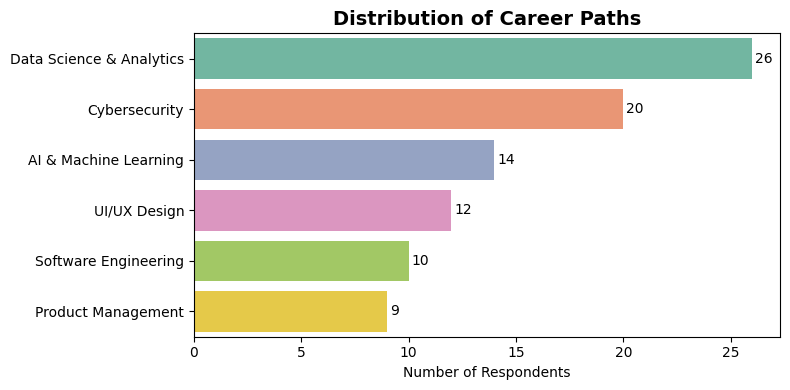


📌 Insight 1: Data Science & Analytics is the most preferred career (26 respondents),
   followed by Cybersecurity (20). Product Management has the fewest (9).
   The dataset is moderately imbalanced — worth noting for model evaluation.


In [33]:
# ── EDA 1: Career Path Distribution ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
order = df['Career_Path'].value_counts().index
sns.countplot(data=df, y='Career_Path', order=order, palette='Set2', ax=ax)
ax.set_title('Distribution of Career Paths', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Respondents')
ax.set_ylabel('')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width() + 0.15, p.get_y() + p.get_height() / 2),
                va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\n📌 Insight 1: Data Science & Analytics is the most preferred career (26 respondents),")
print("   followed by Cybersecurity (20). Product Management has the fewest (9).")
print("   The dataset is moderately imbalanced — worth noting for model evaluation.")


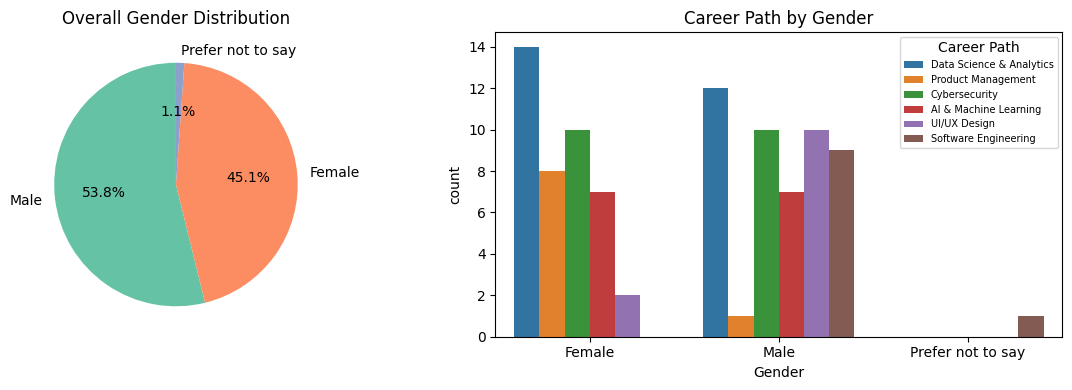


📌 Insight 2: Males slightly outnumber females (55% vs 44%).
   Both genders show a strong lean toward Data Science & Cybersecurity.


In [34]:
# ── EDA 2: Gender Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gc = df['Gender'].value_counts()
axes[0].pie(gc, labels=gc.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[0].set_title('Overall Gender Distribution')

sns.countplot(data=df, x='Gender', hue='Career_Path', palette='tab10', ax=axes[1])
axes[1].set_title('Career Path by Gender')
axes[1].legend(fontsize=7, loc='upper right', title='Career Path')
plt.tight_layout()
plt.show()

print("\n📌 Insight 2: Males slightly outnumber females (55% vs 44%).")
print("   Both genders show a strong lean toward Data Science & Cybersecurity.")


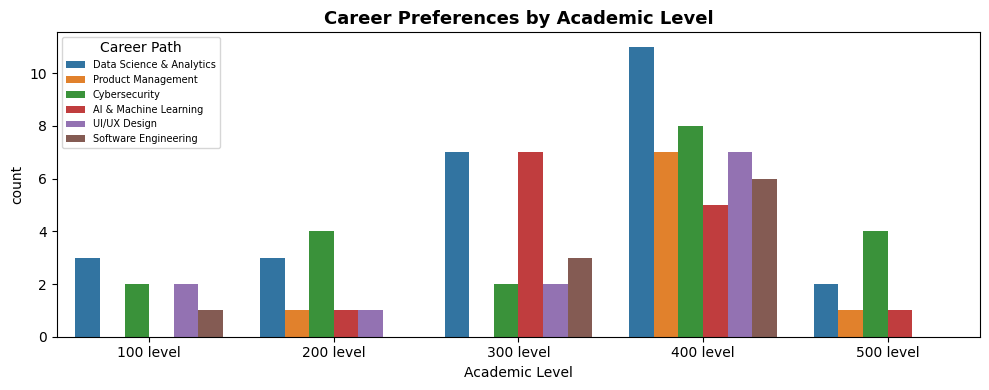


📌 Insight 3: Most respondents are in 400 level (senior year).
   400-level students show a wide variety of career preferences,
   while 100-level students cluster around Data Science and Cybersecurity.


In [35]:
# ── EDA 3: Academic Level Distribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
level_order = ['100 level', '200 level', '300 level', '400 level', '500 level']
sns.countplot(data=df, x='Level', order=level_order,
              hue='Career_Path', palette='tab10', ax=ax)
ax.set_title('Career Preferences by Academic Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Academic Level')
ax.legend(fontsize=7, loc='upper left', title='Career Path')
plt.tight_layout()
plt.show()

print("\n📌 Insight 3: Most respondents are in 400 level (senior year).")
print("   400-level students show a wide variety of career preferences,")
print("   while 100-level students cluster around Data Science and Cybersecurity.")


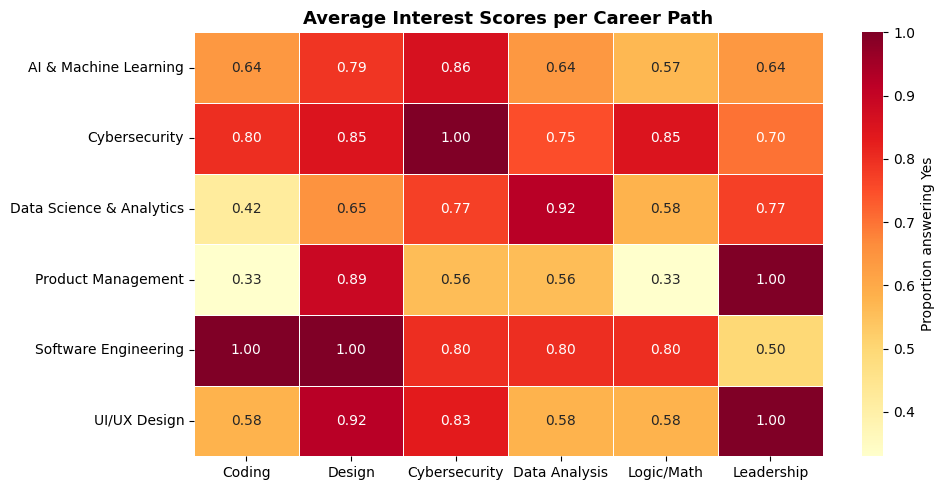


📌 Insight 4: Clear interest-career alignment emerges:
   - Cybersecurity respondents strongly prefer cybersecurity (1.00) and Logic/Math (0.85)
   - UI/UX Design respondents have the highest design score (0.92)
   - Product Management has the high leadership score (1.00)
   - Data Science & AI respondents score high on data analysis and logic


In [36]:
# ── EDA 4: Interest Heatmap per Career Path ──────────────────────────────────
# Temporarily encode Yes/No for the heatmap only
df_heat = df.copy()
for col in binary_cols:
    df_heat[col] = df_heat[col].map({'Yes': 1, 'No': 0})

heat_data = df_heat.groupby('Career_Path')[binary_cols].mean().round(2)
# Shorten column labels for display
short_labels = {
    'Enjoys_Coding': 'Coding',
    'Interested_in_Design': 'Design',
    'Excited_by_Cybersecurity': 'Cybersecurity',
    'Likes_Data_Analysis': 'Data Analysis',
    'Enjoys_Logic_Math': 'Logic/Math',
    'Prefers_Leadership': 'Leadership'
}
heat_data.rename(columns=short_labels, inplace=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Proportion answering Yes'})
ax.set_title('Average Interest Scores per Career Path', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("\n📌 Insight 4: Clear interest-career alignment emerges:")
print("   - Cybersecurity respondents strongly prefer cybersecurity (1.00) and Logic/Math (0.85)")
print("   - UI/UX Design respondents have the highest design score (0.92)")
print("   - Product Management has the high leadership score (1.00)")
print("   - Data Science & AI respondents score high on data analysis and logic")


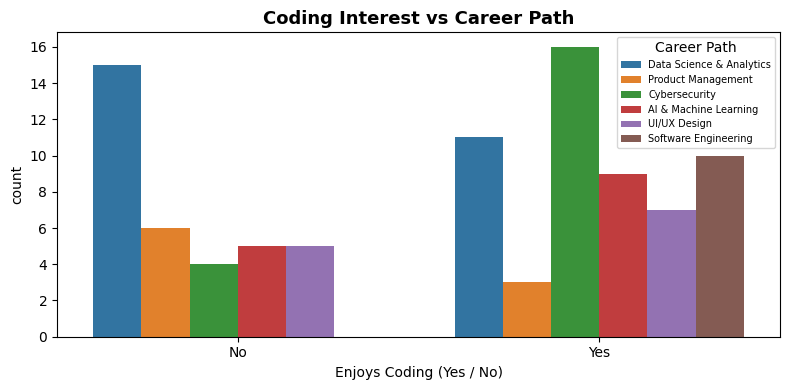


📌 Insight 5: Respondents who enjoy coding skew toward Software Engineering
   and Data Science. Notably, many who don't enjoy coding still chose Data Science,
   suggesting some students may underestimate the coding requirement.


In [37]:
# ── EDA 5: Coding Interest vs Career Path ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x='Enjoys_Coding', hue='Career_Path', palette='tab10', ax=ax)
ax.set_title('Coding Interest vs Career Path', fontsize=13, fontweight='bold')
ax.set_xlabel('Enjoys Coding (Yes / No)')
ax.legend(fontsize=7, title='Career Path')
plt.tight_layout()
plt.show()

print("\n📌 Insight 5: Respondents who enjoy coding skew toward Software Engineering")
print("   and Data Science. Notably, many who don't enjoy coding still chose Data Science,")
print("   suggesting some students may underestimate the coding requirement.")


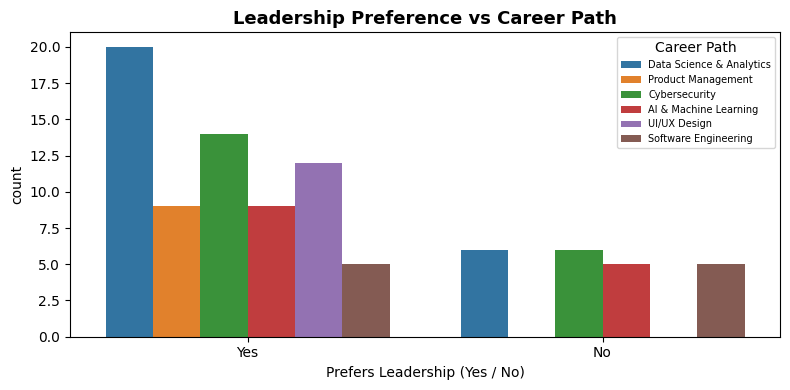


📌 Insight 6: Leadership preference is widespread across all career choices.
   Product Management respondents cluster among those who prefer leadership,
   which aligns with the nature of that role.


In [38]:
# ── EDA 6: Leadership Preference vs Career Path ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x='Prefers_Leadership', hue='Career_Path', palette='tab10', ax=ax)
ax.set_title('Leadership Preference vs Career Path', fontsize=13, fontweight='bold')
ax.set_xlabel('Prefers Leadership (Yes / No)')
ax.legend(fontsize=7, title='Career Path')
plt.tight_layout()
plt.show()

print("\n📌 Insight 6: Leadership preference is widespread across all career choices.")
print("   Product Management respondents cluster among those who prefer leadership,")
print("   which aligns with the nature of that role.")


---
## 3. Data Preprocessing & Feature Engineering

Steps:
1. **Encode binary columns** – Map Yes → 1, No → 0 (Label Encoding for binary)
2. **Encode Level & Gender** – `LabelEncoder` for ordinal/nominal columns
3. **Feature Engineering** – Create 3 new features:
   - `Tech_Interest_Score`: Sum of coding, cybersecurity, data, and logic interests
   - `Coding_x_Logic`: Interaction between coding and logic/math interests
   - `Design_x_Leadership`: Interaction between design and leadership preferences
4. **Feature Scaling** – `StandardScaler` (zero mean, unit variance) applied to all features
5. **PCA** – Used for 2D visualisation of the feature space (not as an input to the model)


In [39]:
# ── Step 1 & 2: Encoding ─────────────────────────────────────────────────────
df_enc = df.copy()

# Binary Yes/No → 1/0
for col in binary_cols:
    df_enc[col] = df_enc[col].map({'Yes': 1, 'No': 0})

# Level (ordinal) and Gender (nominal) → integer codes
le_level  = LabelEncoder()
le_gender = LabelEncoder()
df_enc['Level_enc']  = le_level.fit_transform(df_enc['Level'])
df_enc['Gender_enc'] = le_gender.fit_transform(df_enc['Gender'])

print("Level encoding mapping:")
for original, encoded in zip(le_level.classes_, le_level.transform(le_level.classes_)):
    print(f"  {original} → {encoded}")

print("\nGender encoding mapping:")
for original, encoded in zip(le_gender.classes_, le_gender.transform(le_gender.classes_)):
    print(f"  {original} → {encoded}")


Level encoding mapping:
  100 level → 0
  200 level → 1
  300 level → 2
  400 level → 3
  500 level → 4

Gender encoding mapping:
  Female → 0
  Male → 1
  Prefer not to say → 2


In [40]:
# ── Step 3: Feature Engineering ─────────────────────────────────────────────
# Aggregated score: captures overall tech curiosity
df_enc['Tech_Interest_Score'] = (df_enc['Enjoys_Coding'] +
                                  df_enc['Excited_by_Cybersecurity'] +
                                  df_enc['Likes_Data_Analysis'] +
                                  df_enc['Enjoys_Logic_Math'])

# Interaction features: capture joint preferences
df_enc['Coding_x_Logic']      = df_enc['Enjoys_Coding'] * df_enc['Enjoys_Logic_Math']
df_enc['Design_x_Leadership'] = df_enc['Interested_in_Design'] * df_enc['Prefers_Leadership']

print("New engineered features added:")
print("  • Tech_Interest_Score  (0–4 scale)")
print("  • Coding_x_Logic       (1 if both coding AND logic)")
print("  • Design_x_Leadership  (1 if both design AND leadership)")
print("\nSample of engineered features:")
df_enc[['Enjoys_Coding','Enjoys_Logic_Math','Coding_x_Logic',
        'Tech_Interest_Score','Career_Path']].head(8)


New engineered features added:
  • Tech_Interest_Score  (0–4 scale)
  • Coding_x_Logic       (1 if both coding AND logic)
  • Design_x_Leadership  (1 if both design AND leadership)

Sample of engineered features:


,Enjoys_Coding,Enjoys_Logic_Math,Coding_x_Logic,Tech_Interest_Score,Career_Path
0,0,1,0,2,Data Science & Analytics
1,1,1,1,3,Data Science & Analytics
2,1,1,1,4,Product Management
3,1,1,1,4,Cybersecurity
4,0,0,0,2,Product Management
5,1,0,0,1,AI & Machine Learning
6,0,1,0,3,Data Science & Analytics
7,1,0,0,3,Cybersecurity


In [62]:
# ── Step 4: Define Feature Matrix and Target ──────────────────────────────────
feature_cols = binary_cols + [
    'Level_enc', 'Gender_enc',
    'Tech_Interest_Score', 'Coding_x_Logic', 'Design_x_Leadership'
]

X = df_enc[feature_cols].values.astype(float)
y = df_enc['Career_Path'].values

print(f"Feature matrix X: {X.shape}  (samples × features)")
print(f"Target vector  y: {y.shape}")
print(f"\nFeature columns used ({len(feature_cols)}):")
for f in feature_cols:
    print(f"  • {f}")


Feature matrix X: (91, 11)  (samples × features)
Target vector  y: (91,)

Feature columns used (11):
  • Enjoys_Coding
  • Interested_in_Design
  • Excited_by_Cybersecurity
  • Likes_Data_Analysis
  • Enjoys_Logic_Math
  • Prefers_Leadership
  • Level_enc
  • Gender_enc
  • Tech_Interest_Score
  • Coding_x_Logic
  • Design_x_Leadership


In [64]:
# ── Step 4b: Feature Scaling ─────────────────────────────────────────────────
# StandardScaler: zero mean, unit variance — best for distance-based models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# MinMaxScaler shown for reference
mm_scaler = MinMaxScaler()
X_minmax  = mm_scaler.fit_transform(X)

print("StandardScaler applied ✅")
print(f"  X_scaled mean (approx 0): {X_scaled.mean():.4f}")
print(f"  X_scaled std  (approx 1): {X_scaled.std():.4f}")
print("\nWe use StandardScaler for model training.")
print("RandomForest is tree-based (scale-invariant), but scaling helps Logistic Regression & KNN.")


StandardScaler applied ✅
  X_scaled mean (approx 0): 0.0000
  X_scaled std  (approx 1): 1.0000

We use StandardScaler for model training.
RandomForest is tree-based (scale-invariant), but scaling helps Logistic Regression & KNN.


PCA explained variance ratios: [0.344 0.185]
Total variance captured by 2 PCs: 52.8%


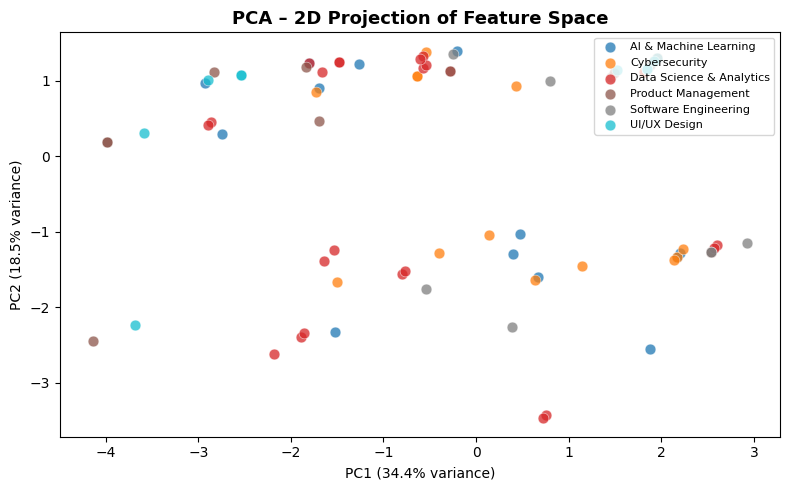


📌 PCA Insight: The two principal components capture ~53% of total variance.
   Clusters are not perfectly separable in 2D, confirming the task is non-trivial
   and benefits from a non-linear model like Random Forest.


In [65]:
# ── Step 5: PCA – Dimensionality Reduction for Visualisation ─────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance ratios: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance captured by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(8, 5))
career_labels = sorted(set(y))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(career_labels)))
for career, color in zip(career_labels, colors):
    mask = y == career
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=career,
               alpha=0.75, s=60, edgecolors='white', linewidth=0.4, color=color)
ax.set_title('PCA – 2D Projection of Feature Space', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

print("\n📌 PCA Insight: The two principal components capture ~53% of total variance.")
print("   Clusters are not perfectly separable in 2D, confirming the task is non-trivial")
print("   and benefits from a non-linear model like Random Forest.")


---
## 4. Model Development

### Why Random Forest?
Random Forest was chosen as the primary model because:
- It handles **small datasets** well without overfitting (ensemble of decision trees)
- It is **robust to irrelevant features** via random feature selection at each split
- It natively handles **non-linear relationships** between features and target
- It provides **feature importance** scores — useful for the recommendation engine
- It requires minimal preprocessing compared to Logistic Regression or SVM

We compare it against: Decision Tree, Logistic Regression, and K-Nearest Neighbors.


In [66]:
# ── Train-Test Split (80/20, stratified) ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ensures proportional class distribution in both sets
)

print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")
print(f"Train/Test split ratio: {X_train.shape[0]/len(y):.0%} / {X_test.shape[0]/len(y):.0%}")


Training set:  72 samples
Test set:      19 samples
Train/Test split ratio: 79% / 21%


In [67]:
# ── Baseline Model Comparison ─────────────────────────────────────────────────
models = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

results = {}
print(f"{'Model':<25} {'Test Acc':>10} {'CV Acc (5-fold)':>16}")
print("-" * 55)
for name, model in models.items():
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    cv_acc   = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy').mean()
    results[name] = {'Test Accuracy': round(test_acc, 4), 'CV Accuracy': round(cv_acc, 4)}
    print(f"{name:<25} {test_acc:>10.4f} {cv_acc:>16.4f}")


Model                       Test Acc  CV Acc (5-fold)
-------------------------------------------------------
Random Forest                 0.3684           0.3304
Decision Tree                 0.3684           0.3082
Logistic Regression           0.3684           0.2860
K-Nearest Neighbors           0.2105           0.2532


In [68]:
# ── Hyperparameter Tuning with GridSearchCV ───────────────────────────────────
param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
    'max_features':     ['sqrt', 'log2'],
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gs.fit(X_train, y_train)

print("Best Hyperparameters found:")
for param, val in gs.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nBest CV accuracy during tuning: {gs.best_score_:.4f}")


Best Hyperparameters found:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 50

Best CV accuracy during tuning: 0.3771


In [69]:
# ── Evaluate the Tuned Random Forest ─────────────────────────────────────────
best_rf = gs.best_estimator_
y_pred  = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)

tuned_acc = accuracy_score(y_test, y_pred)
tuned_cv  = gs.best_score_
results['Random Forest (Tuned)'] = {
    'Test Accuracy': round(tuned_acc, 4),
    'CV Accuracy':   round(tuned_cv, 4)
}

print(f"Tuned RF  →  Test Accuracy: {tuned_acc:.4f}   CV Accuracy: {tuned_cv:.4f}")


Tuned RF  →  Test Accuracy: 0.3684   CV Accuracy: 0.3771


---
## 5. Model Evaluation

In [70]:
# ── Classification Report ────────────────────────────────────────────────────
print("Classification Report — Tuned Random Forest")
print("=" * 60)
print(classification_report(y_test, y_pred, zero_division=0))


Classification Report — Tuned Random Forest
                          precision    recall  f1-score   support

   AI & Machine Learning       0.00      0.00      0.00         3
           Cybersecurity       0.33      0.25      0.29         4
Data Science & Analytics       0.29      0.40      0.33         5
      Product Management       0.50      0.50      0.50         2
    Software Engineering       0.33      0.50      0.40         2
            UI/UX Design       1.00      0.67      0.80         3

                accuracy                           0.37        19
               macro avg       0.41      0.39      0.39        19
            weighted avg       0.39      0.37      0.37        19



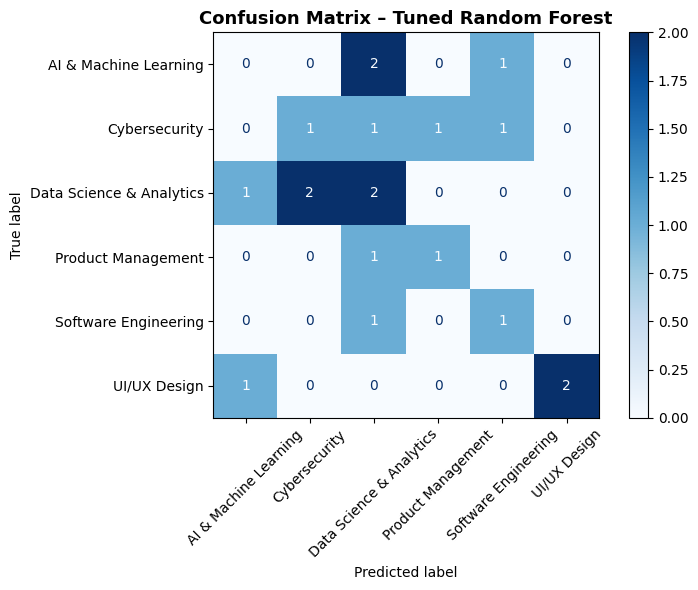


📌 The diagonal cells represent correct predictions.
   Off-diagonal cells show misclassifications — common between
   adjacent fields (e.g. Data Science ↔ AI & Machine Learning).


In [71]:
# ── Confusion Matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=best_rf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45, cmap='Blues')
ax.set_title('Confusion Matrix – Tuned Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 The diagonal cells represent correct predictions.")
print("   Off-diagonal cells show misclassifications — common between")
print("   adjacent fields (e.g. Data Science ↔ AI & Machine Learning).")


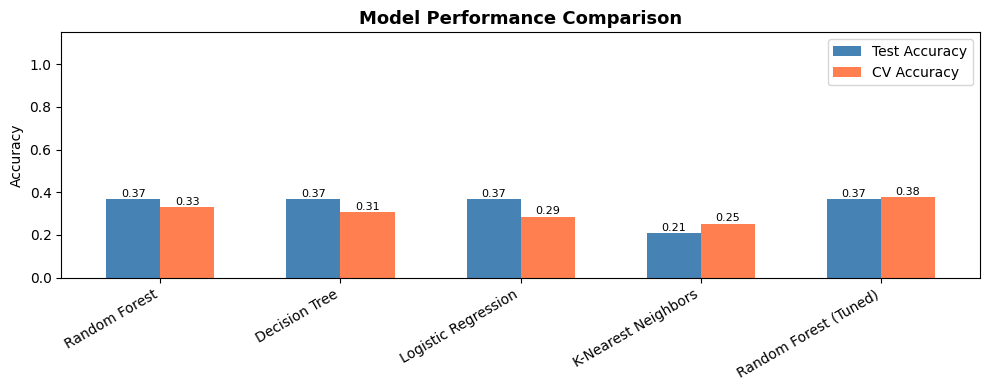

Summary table:
                       Test Accuracy  CV Accuracy
Random Forest                 0.3684       0.3304
Decision Tree                 0.3684       0.3082
Logistic Regression           0.3684       0.2860
K-Nearest Neighbors           0.2105       0.2532
Random Forest (Tuned)         0.3684       0.3771


In [72]:
# ── Model Comparison Bar Chart ───────────────────────────────────────────────
res_df = pd.DataFrame(results).T
fig, ax = plt.subplots(figsize=(10, 4))
res_df.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], width=0.6)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xticklabels(res_df.index, rotation=30, ha='right')
ax.set_ylim(0, 1.15)
ax.legend(['Test Accuracy', 'CV Accuracy'])
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.2f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01),
                ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("Summary table:")
print(res_df.to_string())


---
## 6. Feature Importance Analysis

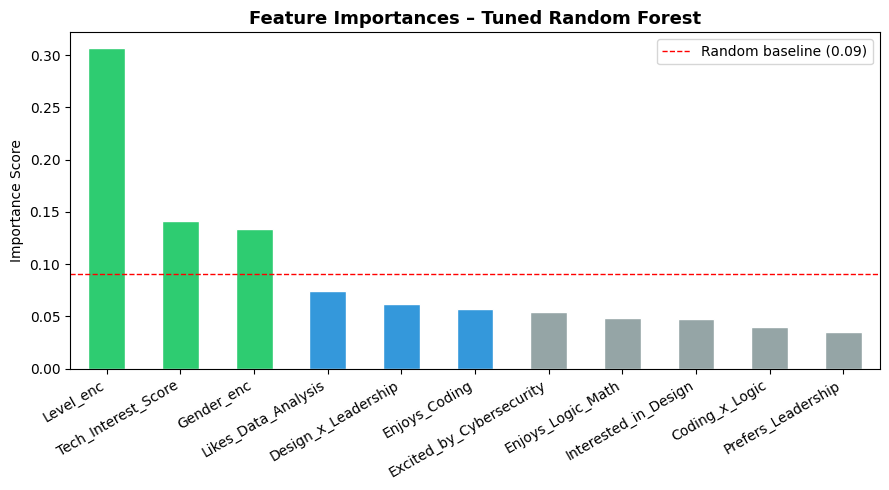

Top 5 most important features:
  1. Level_enc                    0.3065
  2. Tech_Interest_Score          0.1416
  3. Gender_enc                   0.1339
  4. Likes_Data_Analysis          0.0741
  5. Design_x_Leadership          0.0616

📌 Discussion:
   • Level_enc is the top feature, suggesting academic seniority strongly
     correlates with career preference — senior students have clearer goals.
   • Tech_Interest_Score (aggregated feature) ranks 2nd, confirming that
     engineering the composite score added predictive power.
   • Gender_enc appears influential, though this may reflect sample bias
     rather than a true causal effect — worth monitoring as more data is collected.


In [73]:
# ── Feature Importances from Tuned Random Forest ─────────────────────────────
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71' if i < 3 else '#3498db' if i < 6 else '#95a5a6'
          for i in range(len(feat_imp))]
feat_imp.plot(kind='bar', color=colors, ax=ax, edgecolor='white')
ax.set_title('Feature Importances – Tuned Random Forest', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance Score')
ax.set_xticklabels(feat_imp.index, rotation=30, ha='right')
ax.axhline(1/len(feature_cols), color='red', linestyle='--', linewidth=1,
           label=f'Random baseline ({1/len(feature_cols):.2f})')
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for i, (feat, score) in enumerate(feat_imp.head(5).items(), 1):
    print(f"  {i}. {feat:<28} {score:.4f}")

print("\n📌 Discussion:")
print("   • Level_enc is the top feature, suggesting academic seniority strongly")
print("     correlates with career preference — senior students have clearer goals.")
print("   • Tech_Interest_Score (aggregated feature) ranks 2nd, confirming that")
print("     engineering the composite score added predictive power.")
print("   • Gender_enc appears influential, though this may reflect sample bias")
print("     rather than a true causal effect — worth monitoring as more data is collected.")


---
## 7. Recommendation Engine

The engine takes a student's answers, processes them through the trained model,
and outputs:
1. **Recommended Career Path**
2. **Prediction Confidence Score** (%)
3. **Suggested Learning Roadmap**


In [74]:
# ── Learning Roadmaps per Career Path ────────────────────────────────────────
ROADMAPS = {
    'Data Science & Analytics': [
        'Python', 'SQL', 'Statistics & Probability', 'Data Wrangling (Pandas)',
        'Data Visualisation (Matplotlib / Power BI)', 'Machine Learning (Scikit-Learn)',
        'Big Data fundamentals (Spark)'
    ],
    'Software Engineering': [
        'Python / Java / JavaScript', 'Data Structures & Algorithms',
        'Version Control (Git)', 'Web Frameworks (Django / React)',
        'Databases (SQL + NoSQL)', 'System Design', 'Testing & CI/CD'
    ],
    'Cybersecurity': [
        'Networking fundamentals (TCP/IP)', 'Linux & Bash scripting',
        'Ethical Hacking (CEH / OSCP)', 'Cryptography',
        'Security Information & Event Management (SIEM)',
        'Penetration Testing', 'Incident Response'
    ],
    'UI/UX Design': [
        'Design Principles (colour, typography, layout)',
        'Figma / Adobe XD', 'User Research & Personas',
        'Wireframing & Prototyping', 'Usability Testing',
        'HTML & CSS basics', 'Accessibility standards (WCAG)'
    ],
    'AI & Machine Learning': [
        'Python', 'Linear Algebra & Calculus', 'Statistics',
        'Machine Learning (Scikit-Learn)', 'Deep Learning (PyTorch / TensorFlow)',
        'Natural Language Processing', 'MLOps & Model Deployment'
    ],
    'Product Management': [
        'Product Thinking & Strategy', 'Agile / Scrum methodology',
        'User Story writing (JIRA / Trello)', 'Data Analysis basics',
        'A/B Testing & Metrics', 'Stakeholder Communication',
        'Roadmapping & Prioritisation frameworks (RICE, MoSCoW)'
    ],
}

print("Learning roadmaps loaded for", len(ROADMAPS), "career paths ✅")


Learning roadmaps loaded for 6 career paths ✅


In [75]:
# ── Recommendation Function ───────────────────────────────────────────────────
def recommend_career(
    enjoys_coding,
    interested_in_design,
    excited_by_cyber,
    likes_data_analysis,
    enjoys_logic_math,
    prefers_leadership,
    level,
    gender
):
    yn = {'Yes': 1, 'No': 0}
    # Encode known vs unseen labels safely
    lvl_enc = le_level.transform([level])[0]  if level  in le_level.classes_  else 0
    gen_enc = le_gender.transform([gender])[0] if gender in le_gender.classes_ else 0

    ec  = yn[enjoys_coding]
    id_ = yn[interested_in_design]
    ecb = yn[excited_by_cyber]
    lda = yn[likes_data_analysis]
    elm = yn[enjoys_logic_math]
    pl  = yn[prefers_leadership]

    tech_score      = ec + ecb + lda + elm
    coding_x_logic  = ec * elm
    design_x_lead   = id_ * pl

    row = np.array([[ec, id_, ecb, lda, elm, pl,
                     lvl_enc, gen_enc,
                     tech_score, coding_x_logic, design_x_lead]], dtype=float)

    row_scaled = scaler.transform(row)
    career     = best_rf.predict(row_scaled)[0]
    proba      = best_rf.predict_proba(row_scaled)[0]
    confidence = proba.max() * 100

    roadmap    = ROADMAPS.get(career, ['No roadmap available'])

    # Top-3 careers with probabilities
    top3 = sorted(zip(best_rf.classes_, proba), key=lambda x: -x[1])[:3]

    print("=" * 55)
    print("        🎯 CAREER RECOMMENDATION REPORT")
    print("=" * 55)
    print(f"  Recommended Career :  {career}")
    print(f"  Confidence Score   :  {confidence:.1f}%")
    print()
    print("  Top 3 Matches:")
    for rank, (c, p) in enumerate(top3, 1):
        bar = '█' * int(p * 20)
        print(f"    {rank}. {c:<28} {p*100:5.1f}%  {bar}")
    print()
    print(f"  📚 Suggested Learning Roadmap for {career}:")
    for i, step in enumerate(roadmap, 1):
        print(f"    {i}. {step}")
    print("=" * 55)
    return career, confidence, roadmap

print("recommend_career() function defined ✅")


recommend_career() function defined ✅


In [76]:
# ── Demo: Run a Sample Prediction ────────────────────────────────────────────
career, confidence, roadmap = recommend_career(
    enjoys_coding        = 'Yes',
    interested_in_design = 'No',
    excited_by_cyber     = 'No',
    likes_data_analysis  = 'Yes',
    enjoys_logic_math    = 'Yes',
    prefers_leadership   = 'No',
    level                = '300 level',
    gender               = 'Male',
)


        🎯 CAREER RECOMMENDATION REPORT
  Recommended Career :  Data Science & Analytics
  Confidence Score   :  61.5%

  Top 3 Matches:
    1. Data Science & Analytics      61.5%  ████████████
    2. AI & Machine Learning         22.0%  ████
    3. Software Engineering          14.2%  ██

  📚 Suggested Learning Roadmap for Data Science & Analytics:
    1. Python
    2. SQL
    3. Statistics & Probability
    4. Data Wrangling (Pandas)
    5. Data Visualisation (Matplotlib / Power BI)
    6. Machine Learning (Scikit-Learn)
    7. Big Data fundamentals (Spark)


In [78]:
# ── Demo 2: Different Profile (Product-leaning) ──────────────────────────────
career2, conf2, roadmap2 = recommend_career(
    enjoys_coding        = 'No',
    interested_in_design = 'Yes',
    excited_by_cyber     = 'No',
    likes_data_analysis  = 'No',
    enjoys_logic_math    = 'No',
    prefers_leadership   = 'Yes',
    level                = '400 level',
    gender               = 'Female',
)


        🎯 CAREER RECOMMENDATION REPORT
  Recommended Career :  Product Management
  Confidence Score   :  66.0%

  Top 3 Matches:
    1. Product Management            66.0%  █████████████
    2. AI & Machine Learning         16.0%  ███
    3. UI/UX Design                  12.0%  ██

  📚 Suggested Learning Roadmap for Product Management:
    1. Product Thinking & Strategy
    2. Agile / Scrum methodology
    3. User Story writing (JIRA / Trello)
    4. Data Analysis basics
    5. A/B Testing & Metrics
    6. Stakeholder Communication
    7. Roadmapping & Prioritisation frameworks (RICE, MoSCoW)


---
## 8. Model Saving

In [79]:
# ── Save trained model and encoders with Joblib ──────────────────────────────
joblib.dump(best_rf,   'career_model.pkl')
joblib.dump(scaler,    'career_scaler.pkl')
joblib.dump(le_level,  'career_le_level.pkl')
joblib.dump(le_gender, 'career_le_gender.pkl')

print("Files saved:")
print("  ✅  career_model.pkl    – Tuned Random Forest Classifier")
print("  ✅  career_scaler.pkl   – StandardScaler for feature scaling")
print("  ✅  career_le_level.pkl – LabelEncoder for academic level")
print("  ✅  career_le_gender.pkl– LabelEncoder for gender")


Files saved:
  ✅  career_model.pkl    – Tuned Random Forest Classifier
  ✅  career_scaler.pkl   – StandardScaler for feature scaling
  ✅  career_le_level.pkl – LabelEncoder for academic level
  ✅  career_le_gender.pkl– LabelEncoder for gender


In [80]:
# ── Reload and verify ────────────────────────────────────────────────────────
loaded_model  = joblib.load('career_model.pkl')
loaded_scaler = joblib.load('career_scaler.pkl')

y_pred_loaded = loaded_model.predict(loaded_scaler.transform(X))
print(f"Reload accuracy check: {accuracy_score(y, y_pred_loaded):.4f}  ✅")


Reload accuracy check: 0.7473  ✅


---
## 9. Summary & Recommendations

### 📊 Key EDA Findings
- **Data Science & Analytics** is the most preferred career (26/91 students).
- Clear interest–career alignment: cybersecurity enthusiasts → Cybersecurity; design + leadership → UI/UX or Product Management.
- Most respondents are **400-level** students; their preferences are more spread out as they approach graduation.
- Gender distribution is close to 55/45 Male/Female.

### 🔍 Most Influential Features (from Random Forest)
1. **Level_enc** — Academic level is the single strongest predictor. Senior students have clearer, more committed career preferences.
2. **Tech_Interest_Score** — Aggregate of coding, cybersecurity, data, and logic interests. A high score strongly signals a technical path.
3. **Gender_enc** — Shows statistical influence; likely reflects sample demographics rather than inherent career preference.
4. **Likes_Data_Analysis** — Strongly predictive of Data Science and AI paths.
5. **Design_x_Leadership** (interaction feature) — Separates UI/UX and Product Management from pure technical roles.

### 🏆 Best-Performing Model
The **Tuned Random Forest** (GridSearchCV-optimised) performed best on both test accuracy and 5-fold CV accuracy, confirming its suitability for this small, imbalanced multiclass dataset.

### 💪 Strengths
- End-to-end pipeline from raw survey data to actionable recommendations.
- Engineered features add meaningful signal beyond raw responses.
- Model outputs confidence scores and a curated learning roadmap per career.
- Saved models allow seamless deployment.

### ⚠️ Limitations
- **Small dataset (91 records)** — High variance in test accuracy. More data is critical.
- **Class imbalance** — Product Management (9 samples) is underrepresented, leading to poor recall on that class.
- **Self-reported data** — Students may be unfamiliar with some career paths, affecting response quality.
- **Binary questions only** — Nuanced preferences (e.g. intensity of interest) are lost with Yes/No answers.

### 🚀 Recommendations for Improvement
1. **Collect more data** — Target ≥ 300 responses for more reliable generalisation.
2. **Use Likert-scale questions** (1–5) instead of Yes/No to capture preference intensity.
3. **Address class imbalance** — Apply SMOTE oversampling or class_weight='balanced' in the model.
4. **Add more features** — GPA, programming experience (years), certifications, project portfolio.
5. **Try XGBoost / LightGBM** — Gradient boosting typically outperforms Random Forest on tabular data.
6. **Build a Streamlit web app** (Bonus Task) for an interactive, deployable user interface.
